In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install levenshtein jiwer matplotlib pandas datasets soundfile librosa transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.0 MB/s eta 0:00:00


In [3]:
!pip -q install https://github.com/kpu/kenlm/archive/master.zip

     / 553.6 kB 2.2 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
import time
import pandas as pd
import torch
import torchaudio
import jiwer
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys



LIBRISPEECH = "/content/drive/MyDrive/Colab Notebooks/hw2/data/librispeech_test_other/manifest.csv"

In [5]:
import os


def load_manifest(path):
    """Return list of (wav_path, lowercase reference text).

    The CSV stores audio paths relative to the repo root (e.g.
    "data/librispeech_test_other/sample_0.wav"). Resolve each one against the
    manifest's own directory (the wav files sit next to manifest.csv) so it
    works no matter the current working directory.
    """
    base = os.path.dirname(path)
    df = pd.read_csv(path)
    wav_paths = [os.path.join(base, os.path.basename(p)) for p in df["path"]]
    return list(zip(wav_paths, df["text"].str.lower()))


def evaluate(decoder, manifest, method="greedy", limit=None):
    """Run `decoder.decode(..., method)` over a manifest, return (WER, CER, seconds).

    WER/CER are computed corpus-level (jiwer aggregates over the full list),
    which is the standard way to report these metrics.
    """
    samples = load_manifest(manifest)
    if limit:
        samples = samples[:limit]

    refs, hyps = [], []
    t0 = time.perf_counter()
    for wav_path, ref in tqdm(samples, desc=method, leave=False):
        audio, sr = torchaudio.load(wav_path)
        assert sr == 16000, f"expected 16 kHz, got {sr}"
        hyps.append(decoder.decode(audio, method=method))
        refs.append(ref)
    elapsed = time.perf_counter() - t0

    return jiwer.wer(refs, hyps), jiwer.cer(refs, hyps), elapsed


In [6]:
sys.path.append("/content")
from wav2vec2decoder import Wav2Vec2Decoder

## Task 1 — Greedy decoding

In [ ]:
decoder = Wav2Vec2Decoder(lm_model_path=None)

wer, cer, secs = evaluate(decoder, LIBRISPEECH, method="greedy")
print(f"Greedy  |  WER={wer:.2%}  CER={cer:.2%}  ({secs:.1f}s)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


greedy:   0%|          | 0/200 [00:00<?, ?it/s]

Greedy  |  WER=11.22%  CER=3.81%  (401.0s)


## Task 2 — Beam search + `beam_width` sweep

In [ ]:
beam_widths = [1, 3, 10, 50]
rows = []
for bw in beam_widths:
    decoder = Wav2Vec2Decoder(lm_model_path=None, beam_width=bw)
    wer, cer, secs = evaluate(decoder, LIBRISPEECH, method="beam")
    rows.append({"beam_width": bw, "WER": wer, "CER": cer, "seconds": secs})
    print(f"beam_width={bw:<3} |  WER={wer:.2%}  CER={cer:.2%}  ({secs:.1f}s)")

beam_df = pd.DataFrame(rows)
beam_df

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


beam:   0%|          | 0/200 [00:00<?, ?it/s]

beam_width=1   |  WER=11.24%  CER=3.80%  (274.2s)


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

...

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


beam:   0%|          | 0/200 [00:00<?, ?it/s]

beam_width=50  |  WER=11.10%  CER=3.77%  (531.7s)


,beam_width,WER,CER,seconds
0,1,0.112442,0.038031,274.191470
1,3,0.111464,0.037837,278.092151
2,10,0.110731,0.037692,303.041955
3,50,0.110975,0.037692,531.671436


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


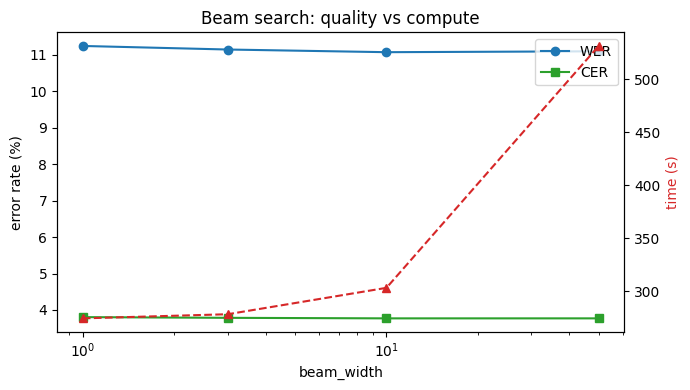

In [ ]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(beam_df["beam_width"], beam_df["WER"] * 100, "o-", color="tab:blue", label="WER")
ax1.plot(beam_df["beam_width"], beam_df["CER"] * 100, "s-", color="tab:green", label="CER")
ax1.set_xlabel("beam_width")
ax1.set_ylabel("error rate (%)")
ax1.set_xscale("log")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(beam_df["beam_width"], beam_df["seconds"], "^--", color="tab:red", label="time")
ax2.set_ylabel("time (s)", color="tab:red")
ax1.set_title("Beam search: quality vs compute")
plt.tight_layout()
plt.show()

## Task 3 — Temperature sweep (greedy)



In [ ]:
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
rows = []
for T in temperatures:
    decoder = Wav2Vec2Decoder(lm_model_path=None, temperature=T)
    wer, cer, _ = evaluate(decoder, LIBRISPEECH, method="greedy")
    rows.append({"T": T, "WER": wer, "CER": cer})
    print(f"T={T:<4} |  WER={wer:.2%}  CER={cer:.2%}")

temp_df = pd.DataFrame(rows)
temp_df

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


greedy:   0%|          | 0/200 [00:00<?, ?it/s]

T=0.5  |  WER=11.22%  CER=3.81%


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


greedy:   0%|          | 0/200 [00:00<?, ?it/s]

T=2.0  |  WER=11.22%  CER=3.81%


,T,WER,CER
0,0.5,0.112198,0.038128
1,0.8,0.112198,0.038128
2,1.0,0.112198,0.038128
3,1.2,0.112198,0.038128
4,1.5,0.112198,0.038128
5,2.0,0.112198,0.038128


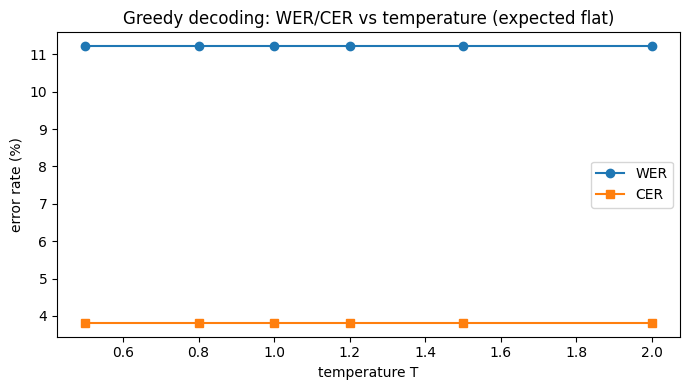

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(temp_df["T"], temp_df["WER"] * 100, "o-", label="WER")
plt.plot(temp_df["T"], temp_df["CER"] * 100, "s-", label="CER")
plt.xlabel("temperature T")
plt.ylabel("error rate (%)")
plt.title("Greedy decoding: WER/CER vs temperature (expected flat)")
plt.legend()
plt.tight_layout()
plt.show()

# Part 2 — Language Model Integration


In [7]:
import numpy as np

BASE = "/content/drive/MyDrive/Colab Notebooks/hw2"
LM_3GRAM = f"{BASE}/lm/3-gram.pruned.1e-7.arpa.gz"
EARNINGS = f"{BASE}/data/earnings22_test/manifest.csv"

BW = 5            # beam width for LM experiments
EVAL_LIMIT = 30   # samples used for sweeps; set None for full 200-sample runs

# Sweep grid (same for shallow fusion and rescoring).
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas  = [0.0, 0.5, 1.0, 1.5]

# One decoder gives us processor+model (for logits) and the KenLM model.
dec = Wav2Vec2Decoder(lm_model_path=LM_3GRAM, beam_width=BW)


def compute_logits_cache(manifest, limit=None):
    """Run the acoustic model ONCE per sample; reuse logits across all sweeps."""
    samples = load_manifest(manifest)
    if limit:
        samples = samples[:limit]
    cache = []
    for wav_path, ref in tqdm(samples, desc="logits", leave=False):
        audio, sr = torchaudio.load(wav_path)
        inputs = dec.processor(audio, return_tensors="pt", sampling_rate=16000)
        with torch.no_grad():
            logits = dec.model(inputs.input_values.squeeze(0)).logits[0]
        cache.append((logits, ref))
    return cache


def eval_on_logits(decode_fn, cache):
    """Corpus-level (WER, CER) for a function logits -> hypothesis string."""
    refs, hyps = [], []
    for logits, ref in cache:
        hyps.append(decode_fn(logits))
        refs.append(ref)
    return jiwer.wer(refs, hyps), jiwer.cer(refs, hyps)


def plot_heatmap(grid, title):
    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(grid * 100, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(len(betas))); ax.set_xticklabels(betas); ax.set_xlabel("beta")
    ax.set_yticks(range(len(alphas))); ax.set_yticklabels(alphas); ax.set_ylabel("alpha")
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f"{grid[i, j] * 100:.1f}", ha="center", va="center",
                    color="w", fontsize=8)
    fig.colorbar(im, label="WER (%)")
    ax.set_title(title)
    plt.tight_layout(); plt.show()


libri_logits = compute_logits_cache(LIBRISPEECH, limit=EVAL_LIMIT)
print("cached logits:", len(libri_logits))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/358 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

logits:   0%|          | 0/30 [00:00<?, ?it/s]

cached logits: 30


## Task 4 — Shallow fusion: `alpha` x `beta` sweep

In [8]:
sf_wer = np.zeros((len(alphas), len(betas)))
for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        dec.alpha, dec.beta = a, b
        wer, cer = eval_on_logits(dec.beam_search_with_lm, libri_logits)
        sf_wer[i, j] = wer
        print(f"alpha={a:<5} beta={b:<4} | WER={wer:.2%} CER={cer:.2%}")

bi, bj = np.unravel_index(np.argmin(sf_wer), sf_wer.shape)
best_sf = (alphas[bi], betas[bj])
print("\nbest shallow fusion (alpha, beta) =", best_sf, f"WER={sf_wer[bi, bj]:.2%}")


alpha=0.01  beta=0.0  | WER=7.56% CER=2.21%
alpha=0.01  beta=0.5  | WER=7.04% CER=2.14%
alpha=0.01  beta=1.0  | WER=6.87% CER=2.14%
alpha=0.01  beta=1.5  | WER=6.87% CER=2.14%
alpha=0.05  beta=0.0  | WER=7.56% CER=2.21%
alpha=0.05  beta=0.5  | WER=7.22% CER=2.14%
alpha=0.05  beta=1.0  | WER=7.04% CER=2.14%
alpha=0.05  beta=1.5  | WER=6.87% CER=2.14%
alpha=0.1   beta=0.0  | WER=7.56% CER=2.21%
alpha=0.1   beta=0.5  | WER=7.22% CER=2.14%
alpha=0.1   beta=1.0  | WER=7.04% CER=2.14%
alpha=0.1   beta=1.5  | WER=6.87% CER=2.14%
alpha=0.5   beta=0.0  | WER=8.08% CER=2.24%
alpha=0.5   beta=0.5  | WER=7.56% CER=2.21%
alpha=0.5   beta=1.0  | WER=7.56% CER=2.17%
alpha=0.5   beta=1.5  | WER=6.70% CER=2.10%
alpha=1.0   beta=0.0  | WER=8.25% CER=2.28%
alpha=1.0   beta=0.5  | WER=8.08% CER=2.24%
alpha=1.0   beta=1.0  | WER=8.08% CER=2.24%
alpha=1.0   beta=1.5  | WER=7.56% CER=2.21%
alpha=2.0   beta=0.0  | WER=11.00% CER=2.62%
alpha=2.0   beta=0.5  | WER=9.28% CER=2.41%
alpha=2.0   beta=1.0  | WER=8.7

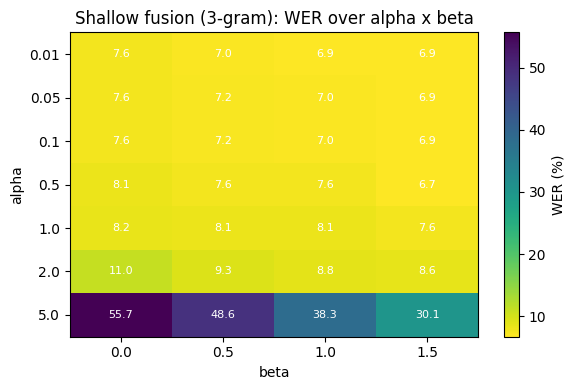

In [9]:
plot_heatmap(sf_wer, "Shallow fusion (3-gram): WER over alpha x beta")


## Task 5 — 4-gram LM (optional)


In [21]:
!wget -q http://www.openslr.org/resources/11/4-gram.arpa.gz -O 4-gram.arpa.gz


In [22]:
dec4 = Wav2Vec2Decoder(lm_model_path="4-gram.arpa.gz", beam_width=BW)
dec4.alpha, dec4.beta = best_sf
wer4, cer4 = eval_on_logits(dec4.beam_search_with_lm, libri_logits)
print(f"4-gram @ {best_sf}: WER={wer4:.2%} CER={cer4:.2%}")


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


4-gram @ (0.5, 1.5): WER=6.87% CER=2.14%


## Task 6 — Rescoring: `alpha` x `beta` sweep (efficient)

In [23]:
dec.beam_width = BW
beams_cache = [(dec.beam_search_decode(logits, return_beams=True), ref)
               for logits, ref in tqdm(libri_logits, desc="beams", leave=False)]

rs_wer = np.zeros((len(alphas), len(betas)))
for i, a in enumerate(alphas):
    for j, b in enumerate(betas):
        dec.alpha, dec.beta = a, b
        refs, hyps = [], []
        for beams, ref in beams_cache:
            hyps.append(dec.lm_rescore(beams))
            refs.append(ref)
        rs_wer[i, j] = jiwer.wer(refs, hyps)
        print(f"alpha={a:<5} beta={b:<4} | WER={rs_wer[i, j]:.2%}")

ri, rj = np.unravel_index(np.argmin(rs_wer), rs_wer.shape)
best_rs = (alphas[ri], betas[rj])
print("\nbest rescoring (alpha, beta) =", best_rs, f"WER={rs_wer[ri, rj]:.2%}")


beams:   0%|          | 0/30 [00:00<?, ?it/s]

alpha=0.01  beta=0.0  | WER=7.56%
alpha=0.01  beta=0.5  | WER=7.56%
alpha=0.01  beta=1.0  | WER=7.90%
alpha=0.01  beta=1.5  | WER=7.90%
alpha=0.05  beta=0.0  | WER=7.56%
alpha=0.05  beta=0.5  | WER=7.56%
alpha=0.05  beta=1.0  | WER=7.90%
alpha=0.05  beta=1.5  | WER=7.90%
alpha=0.1   beta=0.0  | WER=7.56%
alpha=0.1   beta=0.5  | WER=7.56%
alpha=0.1   beta=1.0  | WER=7.90%
alpha=0.1   beta=1.5  | WER=7.90%
alpha=0.5   beta=0.0  | WER=7.90%
alpha=0.5   beta=0.5  | WER=7.56%
alpha=0.5   beta=1.0  | WER=7.56%
alpha=0.5   beta=1.5  | WER=7.56%
alpha=1.0   beta=0.0  | WER=8.08%
alpha=1.0   beta=0.5  | WER=7.90%
alpha=1.0   beta=1.0  | WER=7.90%
alpha=1.0   beta=1.5  | WER=7.56%
alpha=2.0   beta=0.0  | WER=8.59%
alpha=2.0   beta=0.5  | WER=8.42%
alpha=2.0   beta=1.0  | WER=8.08%
alpha=2.0   beta=1.5  | WER=8.08%
alpha=5.0   beta=0.0  | WER=9.62%
alpha=5.0   beta=0.5  | WER=9.62%
alpha=5.0   beta=1.0  | WER=9.62%
alpha=5.0   beta=1.5  | WER=9.62%

best rescoring (alpha, beta) = (0.01, 0.0) WER=

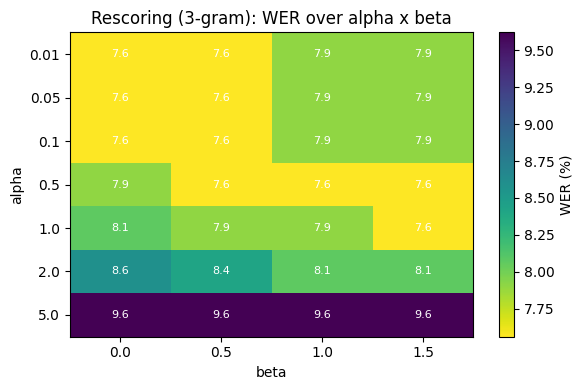

In [24]:
plot_heatmap(rs_wer, "Rescoring (3-gram): WER over alpha x beta")


## Task 6 — Qualitative comparison

In [25]:
shown, MAX_SHOW = 0, 8
for (logits, ref), (beams, _) in zip(libri_logits, beams_cache):
    beam_hyp = dec._ids_to_text(beams[0][0])

    dec.alpha, dec.beta = best_sf
    sf_hyp = dec.beam_search_with_lm(logits)
    dec.alpha, dec.beta = best_rs
    rs_hyp = dec.lm_rescore(beams)

    if beam_hyp != sf_hyp or beam_hyp != rs_hyp:
        print("REF :", ref)
        print("BEAM:", beam_hyp)
        print("SF  :", sf_hyp, "  <-- changed" if sf_hyp != beam_hyp else "")
        print("RS  :", rs_hyp, "  <-- changed" if rs_hyp != beam_hyp else "")
        print()
        shown += 1
        if shown >= MAX_SHOW:
            break


REF : he laughed but it was a curious kind of laugh full of vexation injured amour propre as the french call our love of our own dignity of which archibald raystoke in the full flush of his young belief in his importance as a british officer had a pretty good stock
BEAM: he laughed but it was a curious kind of laugh full of vexation injured amou propra as the prench callar alove of our own dignity of which archabald ray stroke in the full flush of his young belief in his importance as a british officer had a petty good stock
SF  : he laughed but it was a curious kind of laugh full of vexation injured amou propra as the prench callar a love of our own dignity of which archabald ray stroke in the full flush of his young belief in his importance as a british officer had a petty good stock   <-- changed
RS  : he laughed but it was a curious kind of laugh full of vexation injured amou propra as the prench callar alove of our own dignity of which archabald ray stroke in the full flush of his

## Task 7 — Cross-domain comparison (all 4 methods, both test sets)

In [26]:
def eval_all_methods(name, manifest, limit=None):
    cache = compute_logits_cache(manifest, limit=limit)
    beams_c = [(dec.beam_search_decode(l, return_beams=True), r)
               for l, r in tqdm(cache, desc=name + " beams", leave=False)]
    refs = [r for _, r in cache]
    res = {}

    res["Greedy"] = eval_on_logits(dec.greedy_decode, cache)

    beam_hyps = [dec._ids_to_text(b[0][0]) for b, _ in beams_c]
    res["Beam"] = (jiwer.wer(refs, beam_hyps), jiwer.cer(refs, beam_hyps))

    dec.alpha, dec.beta = best_sf
    res["Beam + 3-gram (SF)"] = eval_on_logits(dec.beam_search_with_lm, cache)

    dec.alpha, dec.beta = best_rs
    rs_hyps = [dec.lm_rescore(b) for b, _ in beams_c]
    res["Beam + 3-gram (RS)"] = (jiwer.wer(refs, rs_hyps), jiwer.cer(refs, rs_hyps))
    return res


libri_res = eval_all_methods("libri", LIBRISPEECH, limit=EVAL_LIMIT)
earn_res = eval_all_methods("earn", EARNINGS, limit=EVAL_LIMIT)

table = pd.DataFrame(
    {
        "LibriSpeech WER": [libri_res[m][0] for m in libri_res],
        "LibriSpeech CER": [libri_res[m][1] for m in libri_res],
        "Earnings22 WER": [earn_res[m][0] for m in libri_res],
        "Earnings22 CER": [earn_res[m][1] for m in libri_res],
    },
    index=list(libri_res.keys()),
)
(table * 100).round(2)


logits:   0%|          | 0/30 [00:00<?, ?it/s]

libri beams:   0%|          | 0/30 [00:00<?, ?it/s]

logits:   0%|          | 0/30 [00:00<?, ?it/s]

earn beams:   0%|          | 0/30 [00:00<?, ?it/s]

,LibriSpeech WER,LibriSpeech CER,Earnings22 WER,Earnings22 CER
Greedy,7.90,2.31,50.84,25.82
Beam,7.56,2.17,50.00,25.67
Beam + 3-gram (SF),6.70,2.10,50.84,25.67
Beam + 3-gram (RS),7.56,2.21,50.00,25.67


## Task 7b — Temperature sweep on Earnings22 (greedy vs shallow fusion)

logits:   0%|          | 0/30 [00:00<?, ?it/s]

T=0.5  | greedy WER=50.84%   shallow-fusion WER=51.05%
T=1.0  | greedy WER=50.84%   shallow-fusion WER=50.84%
T=1.5  | greedy WER=50.84%   shallow-fusion WER=52.32%
T=2.0  | greedy WER=50.84%   shallow-fusion WER=55.49%


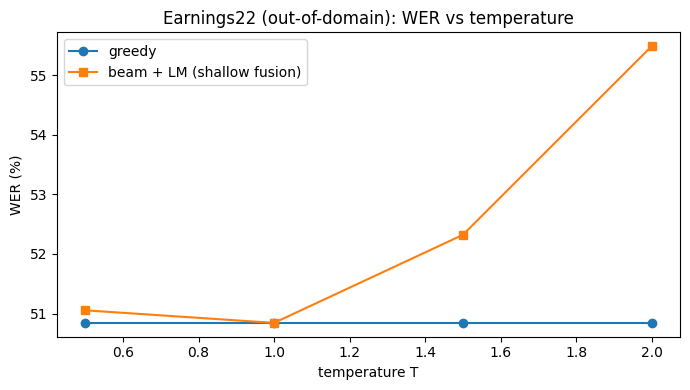

In [27]:
earn_logits = compute_logits_cache(EARNINGS, limit=EVAL_LIMIT)

temps = [0.5, 1.0, 1.5, 2.0]
dec.alpha, dec.beta = best_sf

greedy_curve, sf_curve = [], []
for T in temps:
    g_wer, _ = eval_on_logits(lambda l, T=T: dec.greedy_decode(l / T), earn_logits)
    s_wer, _ = eval_on_logits(lambda l, T=T: dec.beam_search_with_lm(l / T), earn_logits)
    greedy_curve.append(g_wer)
    sf_curve.append(s_wer)
    print(f"T={T:<4} | greedy WER={g_wer:.2%}   shallow-fusion WER={s_wer:.2%}")

plt.figure(figsize=(7, 4))
plt.plot(temps, [w * 100 for w in greedy_curve], "o-", label="greedy")
plt.plot(temps, [w * 100 for w in sf_curve], "s-", label="beam + LM (shallow fusion)")
plt.xlabel("temperature T"); plt.ylabel("WER (%)")
plt.title("Earnings22 (out-of-domain): WER vs temperature")
plt.legend(); plt.tight_layout(); plt.show()


## Task 8 — Train a financial-domain KenLM


In [28]:
!apt-get -qq install -y libboost-all-dev cmake > /dev/null
!git clone --depth=1 https://github.com/kpu/kenlm /tmp/kenlm_build 2>/dev/null
!cmake -S /tmp/kenlm_build -B /tmp/kenlm_build/build > /dev/null 2>&1
!make -C /tmp/kenlm_build/build -j4 lmplz build_binary > /dev/null 2>&1
print("kenlm tools built")


Extracting templates from packages: 100%
kenlm tools built


In [29]:
CORPUS = f"{BASE}/data/earnings22_train/corpus.txt"
FIN_LM = f"{BASE}/lm/financial-3gram.arpa.gz"

!/tmp/kenlm_build/build/bin/lmplz -o 3 --discount_fallback < "{CORPUS}" > /tmp/financial-3gram.arpa
!gzip -cf /tmp/financial-3gram.arpa > "{FIN_LM}"
print("saved:", FIN_LM)


=== 1/5 Counting and sorting n-grams ===
Reading /content/drive/MyDrive/Colab Notebooks/hw2/data/earnings22_train/corpus.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 101181 types 5701
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:68412 2:3785946368 3:7098649600
Statistics:
1 5701 D1=0.568292 D2=1.02526 D3+=1.54415
2 42688 D1=0.761144 D2=1.14769 D3+=1.46089
3 77164 D1=0.868472 D2=1.23411 D3+=1.48545
Memory estimate for binary LM:
type      kB
probing 2501 assuming -p 1.5
probing 2774 assuming -r models -p 1.5
trie    1032 without quantization
trie     574 assuming -q 8 -b 8 quantization 
trie     984 assuming -a 22 array pointer compression
trie     526 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:6

## Task 9 — Two best methods x both LMs x both test sets

In [30]:
libri_beams = beams_cache
earn_beams = [(dec.beam_search_decode(l, return_beams=True), r)
              for l, r in tqdm(earn_logits, desc="earn beams", leave=False)]

lm_paths = {"LibriSpeech 3-gram": LM_3GRAM, "Financial 3-gram": FIN_LM}
datasets = {
    "LibriSpeech": (libri_logits, libri_beams),
    "Earnings22": (earn_logits, earn_beams),
}

records = []
for lm_name, lm_path in lm_paths.items():
    d = Wav2Vec2Decoder(lm_model_path=lm_path, beam_width=BW)
    for ds_name, (logits_cache, beams_c) in datasets.items():
        refs = [r for _, r in logits_cache]

        d.alpha, d.beta = best_sf
        sf_wer, sf_cer = eval_on_logits(d.beam_search_with_lm, logits_cache)

        d.alpha, d.beta = best_rs
        rs_hyps = [d.lm_rescore(b) for b, _ in beams_c]
        rs_wer, rs_cer = jiwer.wer(refs, rs_hyps), jiwer.cer(refs, rs_hyps)

        records.append({"LM": lm_name, "Dataset": ds_name, "Method": "Shallow fusion",
                        "WER": sf_wer, "CER": sf_cer})
        records.append({"LM": lm_name, "Dataset": ds_name, "Method": "Rescoring",
                        "WER": rs_wer, "CER": rs_cer})

task9 = pd.DataFrame(records)
task9_display = task9.copy()
task9_display["WER"] = (task9_display["WER"] * 100).round(2)
task9_display["CER"] = (task9_display["CER"] * 100).round(2)
task9_display


earn beams:   0%|          | 0/30 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,LM,Dataset,Method,WER,CER
0,LibriSpeech 3-gram,LibriSpeech,Shallow fusion,6.70,2.10
1,LibriSpeech 3-gram,LibriSpeech,Rescoring,7.56,2.21
2,LibriSpeech 3-gram,Earnings22,Shallow fusion,50.84,25.67
3,LibriSpeech 3-gram,Earnings22,Rescoring,50.00,25.67
4,Financial 3-gram,LibriSpeech,Shallow fusion,8.76,2.34
5,Financial 3-gram,LibriSpeech,Rescoring,7.56,2.21
6,Financial 3-gram,Earnings22,Shallow fusion,46.84,24.80
7,Financial 3-gram,Earnings22,Rescoring,50.00,25.67


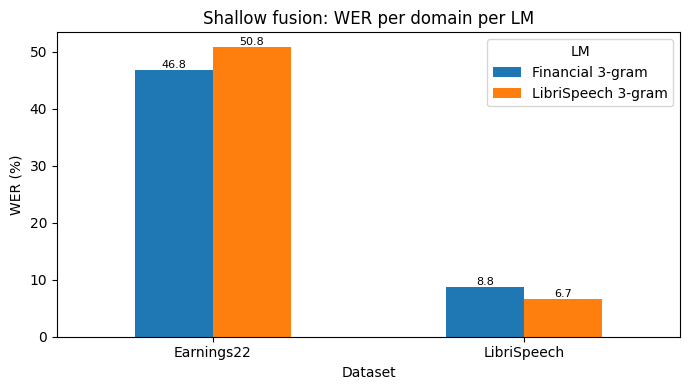

In [31]:
sf = task9[task9["Method"] == "Shallow fusion"]
pivot = sf.pivot(index="Dataset", columns="LM", values="WER") * 100

ax = pivot.plot(kind="bar", figsize=(7, 4), rot=0)
ax.set_ylabel("WER (%)")
ax.set_title("Shallow fusion: WER per domain per LM")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=8)
plt.tight_layout(); plt.show()
